In [145]:
import pandas as pd

In [146]:
df = pd.read_csv(r"C:\Users\hp\Downloads\Churn_Modelling (1).csv")

In [147]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [149]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [150]:
df.isnull().sum()/len(df) *100

RowNumber          0.0
CustomerId         0.0
Surname            0.0
CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
dtype: float64

In [151]:
catg = []
for i in df.columns:
    if df[i].dtype == "object":
        catg.append(i)
print(catg)

['Surname', 'Geography', 'Gender']


In [152]:
num = []
for i in df.columns:
    if df[i].dtype == "int64" or  df[i].dtype == "float64":
        num.append(i)
print(num)

['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [153]:
for i in catg:
    print(df[i].value_counts())
    print("_____________________")

Surname
Smith        32
Scott        29
Martin       29
Walker       28
Brown        26
             ..
Hull          1
Sturdee       1
Flannagan     1
Dwyer         1
Corby         1
Name: count, Length: 2932, dtype: int64
_____________________
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
_____________________
Gender
Male      5457
Female    4543
Name: count, dtype: int64
_____________________


In [154]:
x = df.drop(columns = ['RowNumber', 'CustomerId','Surname','Exited'])

In [155]:
num_all= []
for i in x.columns:
    if x[i].dtype == "int64" or  x[i].dtype == "float64":
        num_all.append(i)
print(num_all)

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [156]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [157]:
y = df['Exited']

In [158]:
y.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

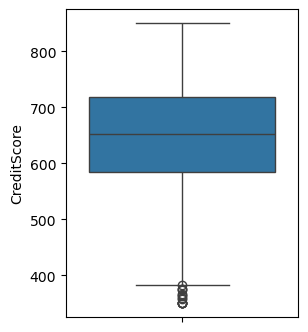

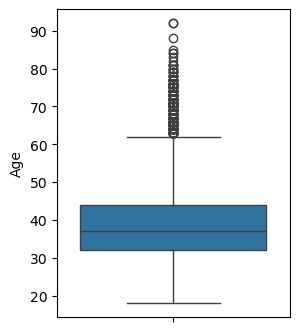

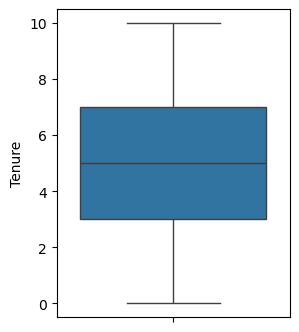

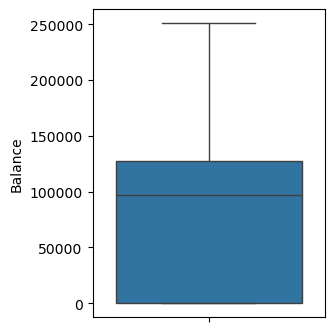

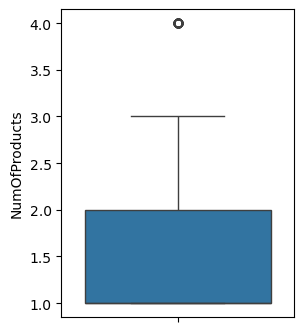

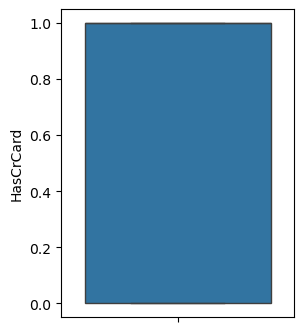

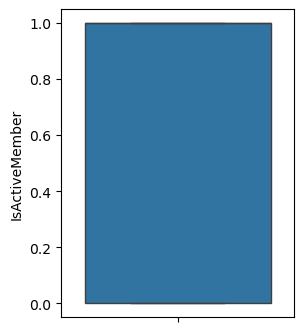

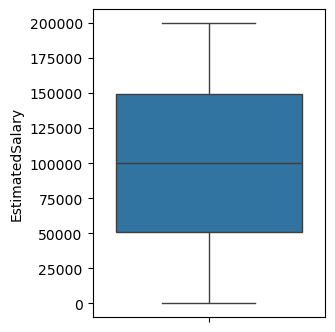

In [160]:
for i in num_all:
    plt.figure(figsize=(3,4))
    sns.boxplot(y=df[i])
    plt.show()

In [161]:
# IQR --find outliers
def check_outliers(x,i):
    Q1=x[i].quantile(0.25)
    Q3=x[i].quantile(0.75)
    IQR=Q3-Q1
    
    lower=Q1-1.5*IQR   # power value 
    upper=Q3+1.5*IQR   # upper value
    
    outliers= x[(x[i]<lower) | (x[i]>upper)]
    return outliers

In [162]:
for i in num_all:
    outliers= check_outliers(x,i)
    print(f"{i} = {len(outliers)}")

CreditScore = 15
Age = 359
Tenure = 0
Balance = 0
NumOfProducts = 60
HasCrCard = 0
IsActiveMember = 0
EstimatedSalary = 0


In [163]:
def treat_outlier(df,i):
    Q1=df[i].quantile(0.25)
    Q3=df[i].quantile(0.75)
    IQR=Q3-Q1
    
    lower=Q1-1.5*IQR   # power value 
    upper=Q3+1.5*IQR   # upper value
    
    df[i]=df[i].clip(lower,upper)
    return df

In [164]:
for i in num:
    df=treat_outlier(df,i)

In [165]:
# Encodding
catg

['Surname', 'Geography', 'Gender']

In [166]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
le_clm =['Gender']
for i in le_clm:
    x[i]=le.fit_transform(x[i])

In [167]:
oe_clm=['Geography']
df=pd.get_dummies(x,oe_clm)

In [168]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,True,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,True,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,True,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,True,False,False
9996,516,1,35,10,57369.61,1,1,1,101699.77,True,False,False
9997,709,0,36,7,0.00,1,0,1,42085.58,True,False,False
9998,772,1,42,3,75075.31,2,1,0,92888.52,False,True,False


In [169]:
# Feature scalling
from sklearn.preprocessing import StandardScaler
sd=StandardScaler()
df[num_all]=sd.fit_transform(df[num_all])

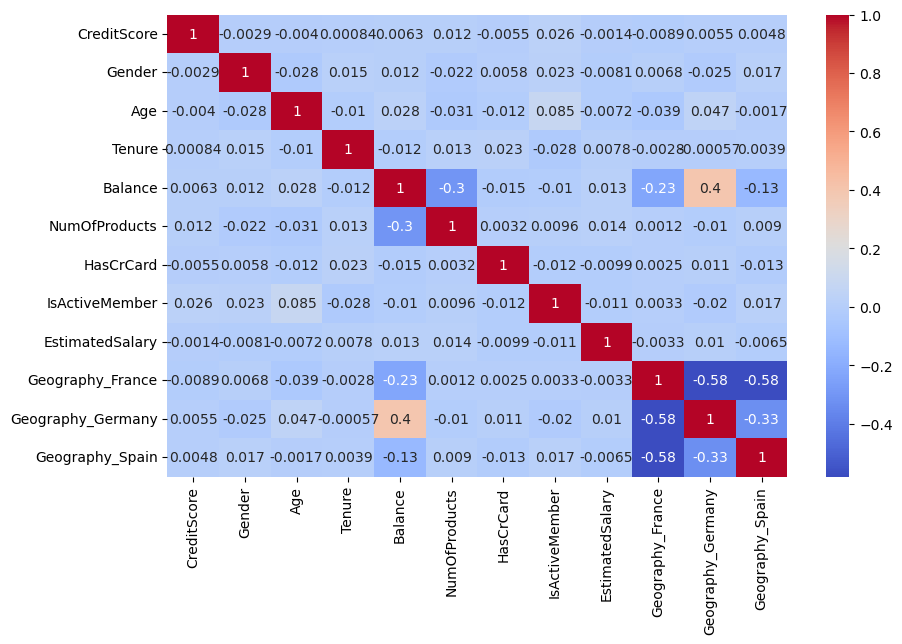

In [170]:
# feature selection
corr = df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [171]:
# treate inbalanced y data

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =train_test_split(df,y,test_size=0.2,random_state=99,stratify=y)

from imblearn.over_sampling import SMOTE
smote= SMOTE(random_state =99)
x_sample,y_sample= smote.fit_resample(x_train,y_train)


In [172]:
from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [173]:
randomforest = RandomForestClassifier(random_state=10,min_samples_leaf=4,n_estimators = 200,max_depth =10,n_jobs = -1)
randomforest.fit(x_sample,y_sample)

RandomForestClassifier(max_depth=10, min_samples_leaf=4, n_estimators=200,
                       n_jobs=-1, random_state=10)

In [174]:
y_pred = randomforest.predict(x_sample)
print("Classification Report:")
print(classification_report(y_sample, y_pred))  
print(f'Accuracy: {accuracy_score(y_sample, y_pred):.2f}')

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      6370
           1       0.89      0.87      0.88      6370

    accuracy                           0.88     12740
   macro avg       0.88      0.88      0.88     12740
weighted avg       0.88      0.88      0.88     12740

Accuracy: 0.88


In [175]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(randomforest, df, y, cv=5)

print("Accuracy of each fold:", scores)
print("Average Accuracy:", scores.mean())

Accuracy of each fold: [0.8615 0.8735 0.8625 0.871  0.859 ]
Average Accuracy: 0.8655000000000002
